# VoxelMorph with a progressive coarse-to-fine field

Extension of Balakrishnan et al. (IEEE TMI 2019) on neurite-OASIS 2D.
Compares the baseline against a progressive variant that predicts one displacement field per
decoder level and warps each level's skip features by the field accumulated so far.

Full-scale results are reported at the end; the training here runs at reduced budget so the
notebook completes in a few minutes.

## 1. Preliminaries

Fetch the code, install dependencies, download and cache the dataset.

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO = (Path('/content/VoxelMorphProject') if IN_COLAB else
        next(d for d in [Path.cwd(), *Path.cwd().parents]
             if (d / 'project' / 'models.py').exists()))

if IN_COLAB and not REPO.exists():
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/viper010404/VoxelMorphProject.git', str(REPO)], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', str(REPO)], check=True)

os.chdir(REPO)
sys.path.insert(0, str(REPO))
print(REPO)

/data/home/ido.falah/VoxelMorphProject


In [2]:
import json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(torch.__version__, DEVICE)

2.5.1+cu121 cuda


Download the 2D dataset (24 MB) and build the cached array plus the train/val/test splits.
The split is seeded, so it is identical on every machine.

In [3]:
UA = 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36'
URL = 'https://surfer.nmr.mgh.harvard.edu/ftp/data/neurite/data/neurite-oasis.2d.v1.0.tar'

Path('data').mkdir(exist_ok=True)
if not Path('data/OASIS_OAS1_0001_MR1').exists():
    # the host rejects curl's default user-agent
    subprocess.run(['curl', '-sSLO', '-A', UA, URL], cwd='data', check=True)
    subprocess.run(['tar', '-xf', 'neurite-oasis.2d.v1.0.tar'], cwd='data', check=True)

if not Path('data/oasis2d.npz').exists():
    subprocess.run([sys.executable, '-m', 'project.prepare_data',
                    '--data-dir', 'data', '--out', 'data/oasis2d.npz'], check=True)
print(sorted(p.name for p in Path('data').glob('oasis2d*')), Path('data/splits.json').exists())

['oasis2d.npz'] True


In [4]:
from project.data import OasisData, PairSampler, default_label_policy, fixed_pairs

data = OasisData('data/oasis2d.npz', device=DEVICE)
splits = data.splits
test_pairs = fixed_pairs(data, 'test', 100, seed=1234)
labels = default_label_policy(data, 'test')

print(f'subjects {len(data)}  image {data.spatial_shape}')
print(f'train {len(splits["train"])}  val {len(splits["val"])}  test {len(splits["test"])}')
print(f'test pairs {len(test_pairs)}  structures {len(labels)}')

subjects 414  image (160, 192)
train 100  val 50  test 100
test pairs 100  structures 14


Every model is scored on this same 100-pair list, so differences can be taken pair by pair.

## 2. Model building

Both models share an identical UNet encoder-decoder. They differ only in how the displacement
field is produced.

### 2.i Base model

Standard VoxelMorph: the decoder runs to full resolution, then one small output path converts
features to a displacement field. `integration_steps > 0` treats that field as a stationary
velocity field and integrates it, which keeps the transform diffeomorphic.

In [5]:
from project.configs import ExperimentConfig
from project.models import build_model

LAMBDA, INT_STEPS = 0.25, 7

base_cfg = ExperimentConfig(name='nb_baseline', variant='baseline', ndim=2,
                            lambda_reg=LAMBDA, integration_steps=INT_STEPS,
                            data_path='data/oasis2d.npz')
baseline = build_model(base_cfg).to(DEVICE)

HEAD_KEYS = ('out_layer', 'flow_layer', 'flow_head')
def head_body(model):
    head = sum(p.numel() for n, p in model.named_parameters() if any(k in n for k in HEAD_KEYS))
    return head, sum(p.numel() for p in model.parameters()) - head

h, b = head_body(baseline)
print(f'baseline   body {b:,}   output head {h:,}   total {h + b:,}')

baseline   body 111,184   output head 72   total 111,256


### 2.ii Progressive model

Same UNet. Each decoder level gets its own flow head, and the fields are accumulated
coarse-to-fine. Before a level runs, its skip features are warped by the field accumulated so
far, so each level only has to explain the residual left by the ones above it.

Deep supervision is off: the loss is still applied once, to the final field.

In [6]:
prog_cfg = ExperimentConfig(name='nb_progressive', variant='pyramid', ndim=2,
                            lambda_reg=LAMBDA, integration_steps=INT_STEPS,
                            pyramid_progressive=True,   # warp skips by the accumulated field
                            deep_supervision=False,     # one loss, on the final field only
                            data_path='data/oasis2d.npz')
progressive = build_model(prog_cfg).to(DEVICE)

h, b = head_body(progressive)
print(f'progressive body {b:,}   output heads {h:,}   total {h + b:,}')
print(f'decoder widths {list(progressive.unet.up_actual_channels)}')
print(f'flow heads     {len(progressive.flow_heads)}')

progressive body 111,184   output heads 2,348   total 113,532
decoder widths [32, 32, 32, 16, 16]
flow heads     5


In [7]:
# resolution and field size at each decoder level
src = torch.zeros(1, 1, *data.spatial_shape, device=DEVICE)
feats = torch.cat([src, src], 1)
skips = []
with torch.no_grad():
    for blk in progressive.unet.downsampling_conv_blocks:
        feats, sk = blk(feats); skips.append(sk)
    feats = progressive.unet.lowest_resolution_conv_block(feats)
    for i, (blk, sk) in enumerate(zip(progressive.unet.upsampling_conv_blocks, reversed(skips))):
        feats = blk(feats, sk)
        print(f'level {i}  {tuple(feats.shape[2:])}  {data.spatial_shape[0] // feats.shape[2]}x downsampled')

level 0  (10, 12)  16x downsampled
level 1  (20, 24)  8x downsampled
level 2  (40, 48)  4x downsampled
level 3  (80, 96)  2x downsampled
level 4  (160, 192)  1x downsampled


In [8]:
import inspect
# the two lines that distinguish the models are the upsample-and-add, and the skip warp
print(inspect.getsource(type(progressive).forward))

    def forward(self, source: torch.Tensor, target: torch.Tensor) -> Dict[str, torch.Tensor]:
        """Register `source` to `target`; returns the per-level fields under `pyramid`."""
        features = torch.cat([source, target], dim=1)

        skips: List[torch.Tensor] = []
        for block in self.unet.downsampling_conv_blocks:
            features, skip = block(features)
            skips.append(skip)
        features = self.unet.lowest_resolution_conv_block(features)

        field = None
        pyramid: List[torch.Tensor] = []

        for head, block, skip in zip(self.flow_heads, self.unet.upsampling_conv_blocks,
                                     reversed(skips)):
            if field is not None:
                field = self._upsample_field(field, skip.shape[2:])
                if self.progressive:
                    skip = self.spatial_transformer(skip, field)

            features = block(features, skip)
            residual = head(features)
            field = resid

## 3. Running the models

The objective is `MSE(fixed, warped_moving) + lambda * grad_smoothness(displacement)`,
identical for both models. `DEMO_STEPS` is well below the budget used for the reported results.

In [9]:
from project.losses import registration_loss
from project.metrics import dice_per_structure, mean_dice, folding, warp_segmentation

DEMO_STEPS = 3000
BATCH = 16

def train(config, steps=DEMO_STEPS, log_every=500):
    torch.manual_seed(config.seed); np.random.seed(config.seed)
    model = build_model(config).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=config.lr)
    sampler = PairSampler(data, 'train', BATCH, seed=config.seed)
    curve, started = [], time.time()

    for step in range(1, steps + 1):
        source, target = next(sampler)
        source, target = source.to(DEVICE), target.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        out = model(source, target)
        losses = registration_loss(target=target, warped_source=out['warped_source'],
                                   disp=out['displacement'], lambda_reg=config.lambda_reg)
        losses['total'].backward()
        opt.step()
        if step % log_every == 0:
            curve.append((step, losses['total'].item()))
            print(f'  {config.name} step {step:>5}/{steps}  loss {losses["total"].item():.5f}')

    print(f'  {config.name} done in {time.time() - started:.0f}s')
    return model, curve

In [10]:
baseline, base_curve = train(base_cfg)

  nb_baseline step   500/3000  loss 0.01494


  nb_baseline step  1000/3000  loss 0.02414


  nb_baseline step  1500/3000  loss 0.02066


  nb_baseline step  2000/3000  loss 0.01815


  nb_baseline step  2500/3000  loss 0.01585


  nb_baseline step  3000/3000  loss 0.01834
  nb_baseline done in 18s


In [11]:
progressive, prog_curve = train(prog_cfg)

  nb_progressive step   500/3000  loss 0.01323


  nb_progressive step  1000/3000  loss 0.02096


  nb_progressive step  1500/3000  loss 0.01796


  nb_progressive step  2000/3000  loss 0.01563


  nb_progressive step  2500/3000  loss 0.01387


  nb_progressive step  3000/3000  loss 0.01586
  nb_progressive done in 23s


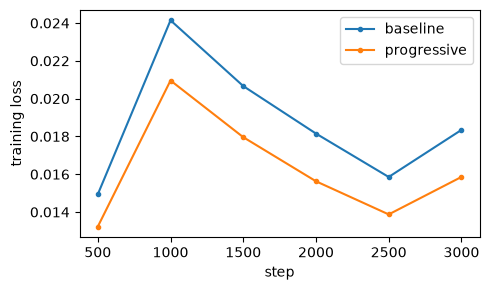

In [12]:
plt.figure(figsize=(5, 3))
for curve, label in [(base_curve, 'baseline'), (prog_curve, 'progressive')]:
    plt.plot(*zip(*curve), marker='o', ms=3, label=label)
plt.xlabel('step'); plt.ylabel('training loss'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Results

Score both models on the 100 fixed test pairs. Dice is averaged over structures present in the
pair; folding is the fraction of voxels with non-positive Jacobian determinant.

In [13]:
@torch.no_grad()
def evaluate(model):
    model.eval()
    rows = []
    for fixed_idx, moving_idx in test_pairs:
        source = data.batch([moving_idx]).to(DEVICE)
        target = data.batch([fixed_idx]).to(DEVICE)
        moving_seg = data.seg_batch([moving_idx]).to(DEVICE)

        out = model(source, target)
        warped_seg = warp_segmentation(moving_seg, out['displacement'])

        fixed_np = data.seg_batch([fixed_idx]).squeeze().cpu().numpy()
        rows.append({
            'dice': mean_dice(dice_per_structure(fixed_np, warped_seg.squeeze().cpu().numpy(), labels)),
            'dice_initial': mean_dice(dice_per_structure(fixed_np, moving_seg.squeeze().cpu().numpy(), labels)),
            'folding': folding(out['displacement'])[0]['fraction'],
        })
    model.train()
    return rows

base_rows = evaluate(baseline)
prog_rows = evaluate(progressive)

In [14]:
def summarise(rows, label):
    d = np.array([r['dice'] for r in rows])
    f = np.array([r['folding'] for r in rows])
    print(f'{label:<12} dice {d.mean():.4f} +- {d.std(ddof=1):.4f}   folding {100 * f.mean():.3f}%')
    return d

print(f'{"unregistered":<12} dice {np.mean([r["dice_initial"] for r in base_rows]):.4f}')
db = summarise(base_rows, 'baseline')
dp = summarise(prog_rows, 'progressive')

diff = dp - db
print(f'\ndifference {diff.mean():+.4f}   progressive better on {int((diff > 0).sum())}/100 pairs')
print(f'paired Wilcoxon p = {stats.wilcoxon(diff).pvalue:.2e}')

unregistered dice 0.6747
baseline     dice 0.7201 +- 0.0636   folding 0.000%
progressive  dice 0.7395 +- 0.0644   folding 0.000%

difference +0.0194   progressive better on 79/100 pairs
paired Wilcoxon p = 1.37e-10


Two caveats on the number above. The p-value compares two single runs, so it is not calibrated
to run-to-run variation, which is the relevant noise when comparing architectures. And
`DEMO_STEPS` is far from convergence, where the gap between the models is at its widest; it
narrows substantially with training. Both are addressed by the full-scale results below.

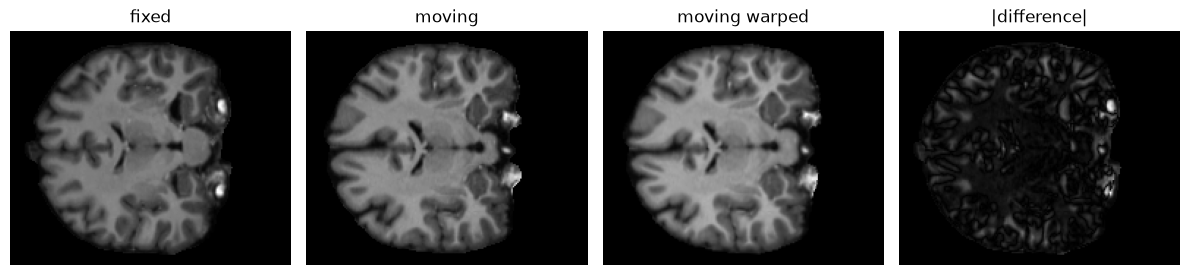

In [15]:
fixed_idx, moving_idx = test_pairs[0]
source = data.batch([moving_idx]).to(DEVICE)
target = data.batch([fixed_idx]).to(DEVICE)
with torch.no_grad():
    warped = progressive.eval()(source, target)

panels = [(target, 'fixed'), (source, 'moving'),
          (warped['warped_source'], 'moving warped'),
          ((target - warped['warped_source']).abs(), '|difference|')]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img.squeeze().cpu().numpy(), cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()

### Full-scale results

The runs above are short. The numbers below come from full training: 2D at 60k steps with 4
seeds per arm, 3D at 80k steps at a single seed. `d` is the change against the matched baseline.

In [16]:
FULL_2D = {  # lambda=0.25, 60k steps, n=4 seeds; sd is over runs, not over pairs
    'baseline':    (0.7566, 0.003333),
    'progressive': (0.7597, 0.000348),
}
FULL_2D_TESTS = {'mean_p': 0.161, 'var_ratio': 91.8, 'var_p': 0.0038}
FULL_3D = {  # 80k steps, seed 0, all with 0.000% folding
    0.025: {'baseline': 0.8066, 'progressive': 0.8128, 'heads only': 0.8072},
    0.05:  {'baseline': 0.8054, 'progressive': 0.8144, 'heads only': 0.8090},
}

print('2D, lambda=0.25, 60k, n=4 seeds')
mb, sb = FULL_2D['baseline']; mp, sp = FULL_2D['progressive']
print(f'  baseline     {mb:.4f} +- {sb:.4f}')
print(f'  progressive  {mp:.4f} +- {sp:.4f}   d {mp - mb:+.4f}'
      f"  (mean p = {FULL_2D_TESTS['mean_p']})")
print(f"  variance ratio {FULL_2D_TESTS['var_ratio']:.0f}x   (F-test p = {FULL_2D_TESTS['var_p']})")

print('\n3D, 80k, seed 0')
for lam, arms in FULL_3D.items():
    base = arms['baseline']
    print(f'  lambda={lam}')
    for name, dice in arms.items():
        tag = '' if name == 'baseline' else f'   d {dice - base:+.4f}'
        print(f'    {name:<12} {dice:.4f}{tag}')

2D, lambda=0.25, 60k, n=4 seeds
  baseline     0.7566 +- 0.0033
  progressive  0.7597 +- 0.0003   d +0.0031  (mean p = 0.161)
  variance ratio 92x   (F-test p = 0.0038)

3D, 80k, seed 0
  lambda=0.025
    baseline     0.8066
    progressive  0.8128   d +0.0062
    heads only   0.8072   d +0.0006
  lambda=0.05
    baseline     0.8054
    progressive  0.8144   d +0.0090
    heads only   0.8090   d +0.0036


`heads only` is the progressive model with the skip warping removed, keeping the per-level flow
heads. It isolates which of the two changes carries the effect.

## 5. Conclusions

- 2D, 60k, 4 seeds: progressive gains +0.0031 Dice, not significant across runs (p = 0.161).
- 2D run-to-run variance drops 92x (F-test p = 0.0038). Baseline seeds span 0.7516-0.7584,
  progressive seeds span 0.7595-0.7602.
- 3D, 80k: progressive gains +0.0090 at lambda=0.05 and +0.0062 at lambda=0.025, with no folding.
- Removing the skip warping and keeping only the per-level heads gives +0.0036 and +0.0006.
  The warping, not the extra heads, carries the effect.
- The 3D gain is larger than the 2D gain. 3D at 80k steps has seen fewer training pairs than 2D
  at 20k, so the two are measured at different points on the convergence curve.

Open: the 3D numbers are single-seed, so run-to-run variance there is unmeasured.